# 230

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('windpower.csv')
df.head()

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275


In [3]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [4]:
df.dropna(inplace=True)
df.isna().sum()

Power (kW)          0
Wind speed (m/s)    0
dtype: int64

In [5]:
y=df['Power (kW)']
x=df[['Wind speed (m/s)']]

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [7]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(369, 1)
(123, 1)
(369,)
(123,)


In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
degree=[3,4,5,6]
MSE=[]
for i in degree:
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    lr=LinearRegression()
    lr.fit(x_train_poly, y_train)
    x_test_poly=poly.fit_transform(x_test)
    y_pred=lr.predict(x_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    MSE.append(mse)
    r2 = r2_score(y_test, y_pred)
    print("Degree=",i)
    print("MSE=", mse)
    print("R2 Score=", r2)
    print()

Degree= 3
MSE= 270.0250095299955
R2 Score= 0.8539264141973832

Degree= 4
MSE= 209.3184510784717
R2 Score= 0.8867664266472862

Degree= 5
MSE= 212.4228861347375
R2 Score= 0.8850870416105098

Degree= 6
MSE= 169.170104193283
R2 Score= 0.9084852037478769



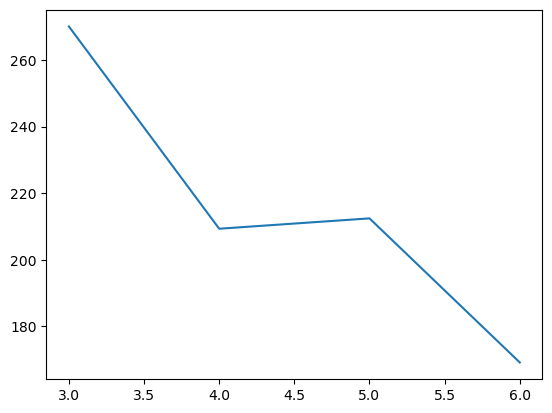

In [11]:
import matplotlib.pyplot as plt
plt.plot(degree,MSE)
plt.show()